<a href="https://colab.research.google.com/github/jayaraksha/Ex4_-24ADI003/blob/main/scenario_2_exp_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gaussian Naive Bayes - Iris Dataset

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset Shape: (150, 5)

Missing Values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

===== GAUSSIAN NAIVE BAYES MODEL EVALUATION ====
Accuracy : 1.0
Precision: 

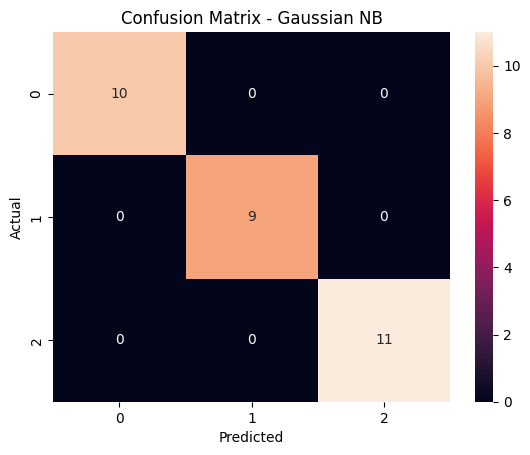


Actual vs Predicted (Gaussian NB - First 10 Rows):
   Actual  Predicted_GNB
0       1              1
1       0              0
2       2              2
3       1              1
4       1              1
5       0              0
6       1              1
7       2              2
8       1              1
9       1              1

Class Probabilities (Gaussian NB - First 5 Test Samples):

[[5.97322611e-090 9.95635768e-001 4.36423247e-003]
 [1.00000000e+000 4.96157683e-014 6.54921950e-021]
 [7.31861098e-290 4.92947289e-012 1.00000000e+000]
 [2.81838335e-094 9.77593560e-001 2.24064404e-002]
 [1.13876385e-105 8.70022604e-001 1.29977396e-001]]

===== LOGISTIC REGRESSION MODEL EVALUATION ====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    a

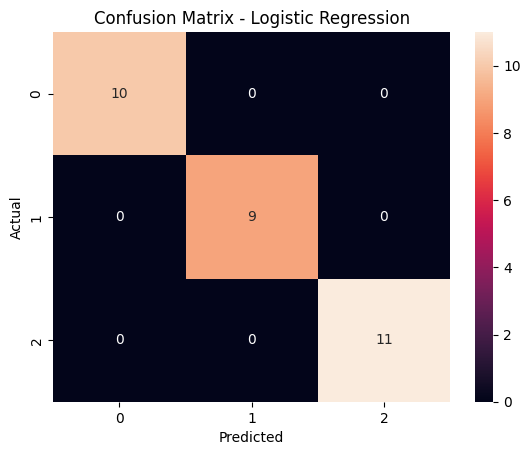


Actual vs Predicted (Logistic Regression - First 10 Rows):
   Actual  Predicted_LR
0       1             1
1       0             0
2       2             2
3       1             1
4       1             1
5       0             0
6       1             1
7       2             2
8       1             1
9       1             1

Class Probabilities (Logistic Regression - First 5 Test Samples):

[[1.14866985e-02 8.74394114e-01 1.14119187e-01]
 [9.65184804e-01 3.48147679e-02 4.27790624e-07]
 [3.95431065e-08 2.96513449e-03 9.97034826e-01]
 [1.34978094e-02 7.58296667e-01 2.28205524e-01]
 [1.88285916e-03 7.49873530e-01 2.48243611e-01]]


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

print("Gaussian Naive Bayes - Iris Dataset")
iris = load_iris()
X = iris.data
y = iris.target
print("\nFeature Names:", iris.feature_names)
print("Target Names:", iris.target_names)
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

print("\n===== GAUSSIAN NAIVE BAYES MODEL EVALUATION ====")
print("Accuracy :", accuracy_score(y_test, y_pred_gnb))
print("Precision:", precision_score(y_test, y_pred_gnb, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_gnb, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_gnb, average='weighted'))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gnb))

cm_gnb = confusion_matrix(y_test, y_pred_gnb)
plt.figure()
sns.heatmap(cm_gnb, annot=True, fmt='d')
plt.title("Confusion Matrix - Gaussian NB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

comparison_gnb = pd.DataFrame({
    "Actual": y_test,
    "Predicted_GNB": y_pred_gnb
})
print("\nActual vs Predicted (Gaussian NB - First 10 Rows):")
print(comparison_gnb.head(10))
print("\nClass Probabilities (Gaussian NB - First 5 Test Samples):\n")
print(gnb.predict_proba(X_test[:5]))

# Logistic Regression
lr = LogisticRegression(max_iter=200) # Increased max_iter for convergence
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n===== LOGISTIC REGRESSION MODEL EVALUATION ====")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_lr, average='weighted'))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

comparison_lr = pd.DataFrame({
    "Actual": y_test,
    "Predicted_LR": y_pred_lr
})
print("\nActual vs Predicted (Logistic Regression - First 10 Rows):")
print(comparison_lr.head(10))
print("\nClass Probabilities (Logistic Regression - First 5 Test Samples):\n")
print(lr.predict_proba(X_test[:5]))